# TTD Price Impact — DiD by bucket & ATE across multiple metrics

A generalized version of `TTD3_Pricing.ipynb`'s DiD-by-bucket and ATE
(Route 1: bucket-weighted ATT) analysis, parameterized over a **list of
outcome metrics** instead of just `Data_Cost`. No RF/Ridge demand-curve
model section — this notebook is DiD + ATE only.

Cells through `dat1`/`dat1_filled` are copied verbatim from
`TTD3_Pricing.ipynb` (same data load, zero-fill panel, bucket assignment).
Everything from the DiD construction onward is new/generalized.

## Default metric list

```
Data_Cost, Avg_Relevance, Avg_Relevance_Percentile, Avg_Value_Percentile,
Avg_Value_Score, Effective_Impression_Count, Match_Pct, Match_Pct_Percentile,
Paid_Pct, Paid_Pct_Percentile
```

## Design decisions (confirmed before building)

1. **Missing-week handling differs by metric type.** `Data_Cost` and
   `Effective_Impression_Count` are *volume* metrics — a missing week
   genuinely means $0 / 0 impressions, so `dat1_filled`'s zero-fill (already
   built into the shared setup cells below) is correct as-is. The other 8
   metrics are *quality/rate* metrics — a zero-activity week has an
   **undefined** relevance/match/value, not a value of 0. Those columns were
   deliberately **not** zero-filled in `dat1_filled` (only `Data_Cost` and
   `Effective_Impression_Count` get an explicit `.fillna(0.0)` there), so
   missing weeks for quality metrics simply stay `NaN` and get dropped
   naturally by `.mean()` (skipna) and the various `.dropna()` calls below —
   no extra code needed, but worth calling out explicitly since it's the
   difference between this working correctly and silently fabricating a
   decline.
2. **"Recommended delta by bucket"** (pick whichever delta maximizes the
   metric, or "do nothing" if both underperform the control) is applied to
   **all** metrics, not just `Data_Cost`.
3. **Relative-DiD framing differs by metric type.** `Data_Cost` and
   `Effective_Impression_Count` keep the ratio-to-control-level framing plus
   portfolio-level extrapolation (dollar/count totals). The 8 percentile/pct
   metrics report **absolute point-change** only — a ratio-to-control framing
   is awkward for an already-bounded (0-100) scale, and "total portfolio
   percentile points" isn't a meaningful quantity to extrapolate.

**Caveat found while building this**: NaN rates for the quality/rate metrics
vary a lot by column — `Avg_Relevance`/`Avg_Relevance_Percentile` have **zero**
missingness even at `Received_ID_Count==0` (they behave like a static,
activity-independent segment attribute), `Avg_Value_Percentile`/
`Avg_Value_Score` are ~40% missing (only partly explained by zero activity),
and `Match_Pct`/`Paid_Pct` (+ their percentiles) are ~38% missing, closely
tracking `Received_ID_Count==0`. The notebook prints per-metric coverage so
this is visible rather than silently baked in.

In [1]:
import datetime
print(f"run @ {datetime.datetime.today().strftime('%Y%m%d-%H:%M:%S')}")

run @ 20260720-10:52:02


In [2]:
last_pre_week = "2026-05-24"
#test_df_start = "2026-05-01"
test_df_start = "2026-04-10"
#test_df_start = "2026-03-01"
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}
# Bucket definition -- absolute revenue cutoffs (adjust as needed). Applied to
# `pricing['revenue']` right after it's loaded below, replacing the original
# rank-window bucket assignment.
#
# BUCKET_BOUNDARIES is a list of lower-bound revenue thresholds, any length,
# sorted descending. A segment's bucket is the largest boundary its revenue
# meets or exceeds (labeled by that boundary value); anything below the
# smallest boundary falls into '0', the catch-all (also its label). E.g. with
# [1000, 100, 10, 1]: revenue=250 -> '100' (>=100, <1000); revenue=0.4 -> '0'.
# Try a different number of buckets or different cutoffs by editing this one
# list -- BUCKET_ORDER, colors, subplot grids, and the ATE weighting all derive
# from it below (see the reassignment cell right after `pricing` is loaded).
BUCKET_BOUNDARIES = [1000, 100, 10, 1]


In [3]:
#adv_type = "Automotive"
adv_type = "All"

In [4]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"
#ttd_file = f"{data_path}/TTD-20260608.csv"
#ttd_file = f"{data_path}/TTD-20260615.csv"
#ttd_file = f"{data_path}/TTD-20260623.csv"
ttd_file = f"{data_path}/TTD-20260714-AllOnly.csv"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import matplotlib

In [7]:
import seaborn as sns

In [8]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [9]:
dat0 = pd.read_csv(ttd_file, low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [10]:
# ─── Load Ranked_by_Revenue early — bucket assignment (below) needs it ────────
# Loaded here (rather than only in the later "Full revenue pool" cell) so bucket
# assignment can join against it directly instead of trusting pricing['revenue']
# to already match -- see the bucket-reassignment cell right after this one.
ttd_path = '/Users/ravirajan/Projects/TTD'
in_p = f"{ttd_path}/Ranked_by_Revenue.csv"
rev_pool = pd.read_csv(in_p)
# Missing revenue = $0/mo, not "unknown" -- left as NaN, it silently fails
# every revenue-gated comparison downstream (bucket assignment, any <=/>=
# threshold rule) rather than being an explicit, visible decision.
rev_pool['revenue'] = rev_pool['revenue'].fillna(0)


In [11]:
# ─── Assign bucket on Ranked_by_Revenue, then join onto pricing ──────────────
# Bucket is computed on the fly for every segment in `rev_pool` (the full
# Ranked_by_Revenue universe) -- not just pricing's ~2000 experiment candidates
# -- using directly-tunable revenue thresholds (BUCKET_BOUNDARIES at the top of
# the notebook). It's then joined onto `pricing` by (Full_Path, Provider).
# Computing it on the universe first (rather than only on pricing's own
# `revenue` column) means the same bucket definition is available for the full
# population too -- used below to weight the ATE by the true population's
# bucket composition, not just the experiment's candidate pool.
#
# Every downstream use of `bucket` (did_b, outlier tables, ATE bucket weights,
# did_vol) reads from pricing['bucket'], so this one join propagates everywhere
# without needing to touch each site individually.
#
# IMPORTANT -- time scale: `rev_pool` (Ranked_by_Revenue.csv) is a MONTHLY
# revenue figure (see the "Full revenue pool" cell below). BUCKET_BOUNDARIES
# are therefore monthly thresholds -- a different time scale from everything
# else in the DiD/ATE analysis (`dat`/`dat1_filled`/`did`/`total_panel_weekly_rev`,
# all WEEKLY Data_Cost). A segment labeled '100+' clears $100/month, not
# $100/week -- don't compare a bucket label directly against a weekly $ figure.

# Sort descending regardless of input order, and de-dup -- np.select's
# first-match-wins semantics require descending order to pick the largest
# boundary a segment clears; a duplicate would make one of the two labels
# unreachable.
_boundaries = sorted(set(BUCKET_BOUNDARIES), reverse=True)
assert len(_boundaries) == len(BUCKET_BOUNDARIES), \
    "BUCKET_BOUNDARIES has duplicate values -- each boundary must be unique"
assert len(_boundaries) >= 1, "BUCKET_BOUNDARIES must have at least one value"

def _fmt(x):
    """Label for a boundary value -- '1000+' not '1000.0', '0.05+' not '0.05000'."""
    return f"{x:g}+"

_labels = [_fmt(b) for b in _boundaries]          # descending, matches _boundaries
ZERO_BUCKET_LABEL = '0+'                           # catch-all below the smallest boundary

# BUCKET_ORDER: ascending (lowest revenue -> highest), for consistency with how
# every downstream plot/table already expects to iterate buckets low-to-high.
BUCKET_ORDER = [ZERO_BUCKET_LABEL] + list(reversed(_labels))

# ── bucket on the full universe (rev_pool) ────────────────────────────────────
_rev_pool_revenue = rev_pool['revenue'].fillna(0.0)
rev_pool['bucket'] = np.select(
    [_rev_pool_revenue >= b for b in _boundaries],
    _labels,
    default=ZERO_BUCKET_LABEL
)

# ── join that bucket assignment onto pricing (the experiment/candidate table) ─
# pricing is itself built as a subset of Ranked_by_Revenue (see
# TTD_Pricing_Simple_Experiment.ipynb), so every (Full_Path, Provider) key in
# pricing is expected to exist in rev_pool -- verified below, this is a key
# match, not a revenue-value match. Separately, rev_pool's own `revenue` column
# is null for some of those matched rows (the segment exists in the file, but
# with no reported revenue) -- already handled by the .fillna(0.0) above before
# bucketing, so it shows up as '0+', not as a join failure.
_bucket_by_seg = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['bucket']
pricing['bucket'] = (
    pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(_bucket_by_seg)
)
_n_key_unmatched = pricing['bucket'].isna().sum()
pricing['bucket'] = pricing['bucket'].fillna(ZERO_BUCKET_LABEL)
_n_null_revenue = pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(
    rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id'])
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']
).isna().sum()
print(f"Bucketing: {len(pricing) - _n_key_unmatched:,} of {len(pricing):,} pricing segments found by key "
      f"in Ranked_by_Revenue.csv ({_n_key_unmatched:,} key not found, treated as {ZERO_BUCKET_LABEL} / $0 monthly)")
print(f"  of those found, {_n_null_revenue:,} have a null revenue value in Ranked_by_Revenue itself "
      f"(segment exists, revenue unreported) -- also treated as $0 monthly, so still '{ZERO_BUCKET_LABEL}'")

# ── Ensure every experiment group stays within a single bucket ────────────────
# `bucket` is a per-segment (revenue-based) label, but `group` pairs segments
# together for control-matching in the DiD (each group has n members, one per
# delta -- typically 3 for -/0/+, sometimes 6 for two of each). If a group's
# revenue straddles a boundary, its members can land in different buckets --
# silently mixing revenue tiers into the same control-matched comparison (a
# treated segment's own control partner could end up counted in a different
# bucket's analysis). Rather than drop these edge cases, move the WHOLE group
# to a single bucket via majority vote among its members.
#
# IMPORTANT: `group` numbers restart at 0 independently per provider (e.g.
# dav2shreths group 2 and sharethis group 2 are unrelated experimental units
# that happen to share an integer id) -- grouping by `group` alone would
# silently merge two different providers' groups into one check. Group by
# (Provider, group) instead.
#
# Ties (e.g. a 6-member group split evenly 3-3) are broken by the bucket of the
# group's median-revenue member -- deterministic, no data dropped either way.
# In practice, grouping correctly by provider leaves no genuine ties: the only
# spanning groups that remain are clean majorities (3-member groups can only
# split 2-1), verified below via _n_ties. The tiebreak code is kept regardless,
# in case a future BUCKET_BOUNDARIES choice or larger group size produces one.
_group_bucket_counts = pricing.groupby(['Third_Party_Data_Provider_Id', 'group'])['bucket'].nunique()
_spanning_groups = _group_bucket_counts[_group_bucket_counts > 1].index  # MultiIndex of (provider, group)
print(f"\nGroups spanning more than one bucket: {len(_spanning_groups)} of {len(_group_bucket_counts)}")

if len(_spanning_groups) > 0:
    _bucket_by_seg_rev = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
        .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']
    pricing['_bucketing_revenue'] = pricing.set_index(
        ['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(_bucket_by_seg_rev)
    pricing['_bucketing_revenue'] = pricing['_bucketing_revenue'].fillna(0.0)

    _n_reassigned, _n_ties = 0, 0
    for prov, g in _spanning_groups:
        mask = (pricing['Third_Party_Data_Provider_Id'] == prov) & (pricing['group'] == g)
        sub = pricing.loc[mask]
        counts = sub['bucket'].value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1:
            winner = top[0]
        else:
            _n_ties += 1
            median_rev = sub['_bucketing_revenue'].median()
            winner = sub.loc[(sub['_bucketing_revenue'] - median_rev).abs().idxmin(), 'bucket']
        _n_reassigned += int((sub['bucket'] != winner).sum())
        pricing.loc[mask, 'bucket'] = winner

    pricing.drop(columns=['_bucketing_revenue'], inplace=True)
    print(f"  reassigned {_n_reassigned} segments to their group's majority bucket ({_n_ties} groups needed tie-break)")

assert (pricing.groupby(['Third_Party_Data_Provider_Id', 'group'])['bucket'].nunique() <= 1).all(), \
    "a (provider, group) still spans multiple buckets after majority-rule correction"

# Shared color map, keyed by bucket name, used everywhere a per-bucket color is
# needed (bar/violin/scatter plots) so it automatically covers however many
# tiers BUCKET_BOUNDARIES currently implies.
BUCKET_COLORS = dict(zip(BUCKET_ORDER, plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, len(BUCKET_ORDER)))))

# Verify: every rev_pool row landed in exactly one bucket (no overlap, no gap),
# and each bucket's members actually satisfy that bucket's own revenue range.
assert rev_pool['bucket'].isin(BUCKET_ORDER).all(), "found a bucket label outside BUCKET_ORDER"
assert rev_pool['bucket'].notna().all(), "found an unassigned (NaN) bucket"
for i, label in enumerate(_labels):
    lo = _boundaries[i]
    hi = _boundaries[i - 1] if i > 0 else None   # None -> no upper bound (top bucket)
    in_bucket = _rev_pool_revenue[rev_pool['bucket'] == label]
    assert (in_bucket >= lo).all(), f"a '{label}' row is below its own lower bound ({lo})"
    if hi is not None:
        assert (in_bucket < hi).all(), f"a '{label}' row reaches the next boundary up ({hi}), should be '{_fmt(hi)}'"
below_smallest = _rev_pool_revenue[rev_pool['bucket'] == ZERO_BUCKET_LABEL]
assert (below_smallest < _boundaries[-1]).all(), f"a '{ZERO_BUCKET_LABEL}' row clears the smallest boundary ({_boundaries[-1]})"
assert pricing['bucket'].isin(BUCKET_ORDER).all(), "pricing bucket join produced a label outside BUCKET_ORDER"

print(f"Bucket assigned from monthly-revenue boundaries {_boundaries} (labels: {BUCKET_ORDER}):")
print("rev_pool (full universe):")
print(rev_pool.groupby(['Third_Party_Data_Provider_Id', 'bucket']).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER))
print("pricing (experiment candidates, joined from rev_pool):")
print(pricing.groupby(['Third_Party_Data_Provider_Id', 'bucket']).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER))


Bucketing: 2,037 of 2,037 pricing segments found by key in Ranked_by_Revenue.csv (0 key not found, treated as 0+ / $0 monthly)
  of those found, 567 have a null revenue value in Ranked_by_Revenue itself (segment exists, revenue unreported) -- also treated as $0 monthly, so still '0+'

Groups spanning more than one bucket: 2 of 679
  reassigned 2 segments to their group's majority bucket (0 groups needed tie-break)
Bucket assigned from monthly-revenue boundaries [1000, 100, 10, 1] (labels: ['0+', '1+', '10+', '100+', '1000+']):
rev_pool (full universe):
bucket                          0+   1+  10+  100+  1000+
Third_Party_Data_Provider_Id                             
dav2shreths                   1706  251  147    37      5
sharethis                     2364  535  442   207     32
pricing (experiment candidates, joined from rev_pool):
bucket                         0+   1+  10+  100+  1000+
Third_Party_Data_Provider_Id                            
dav2shreths                   720  171  

In [12]:
dat0['Week_Start_Date'].max()

'2026-06-29 00:00:00+00'

In [13]:
dat0.head(3)

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,204688200.0,97.3,All,4.2,79.5,94.0,58.0,0.09,8612.0,Data Alliance > Education > Interest > Global ...,...,88.3,23.7,80.2,465473100.0,0.0024,83.1,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,All,4.3,80.2,NaN,NaN,NaN,NaN,Data Alliance > Pets & Animals > Interest > Gl...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,183006000.0,97.1,All,4.3,81.0,94.0,58.0,31.09,232037.0,Data Alliance > Shopping > Interest > Global >...,...,96.6,88.8,93.2,418018700.0,0.0133,95.5,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [14]:
pricing.head(3)    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,1000+
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,1000+
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,1000+


In [15]:
dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

In [16]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta', 'bucket']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta'] * dat['post']  # delta only applies post-treatment
    return dat


In [17]:
dat = add_prices(dat, base_PoM_default, pricing)

In [18]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [19]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [20]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.014209
Asia,0.013768
Global,0.472449
US,0.330870
Unknown,0.168704


In [21]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,312.0,0.150000,8.340049e-16,0.15,0.15,0.15,0.15,0.15
Asia,31720.0,0.150016,4.045625e-04,0.15,0.15,0.15,0.15,0.16
Global,82238.0,0.156775,1.641791e-02,0.10,0.15,0.16,0.16,0.21
US,21606.0,0.150000,5.715005e-14,0.15,0.15,0.15,0.15,0.15
Unknown,13349.0,0.150019,4.409154e-04,0.15,0.15,0.15,0.15,0.16


In [22]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,312.0,0.150000,8.340049e-16,0.15,0.15,0.15,0.15,0.15
Asia,31720.0,0.150016,4.045625e-04,0.15,0.15,0.15,0.15,0.16
Global,82238.0,0.156775,1.641791e-02,0.10,0.15,0.16,0.16,0.21
US,21606.0,0.150000,5.715005e-14,0.15,0.15,0.15,0.15,0.15
Unknown,13349.0,0.150019,4.409154e-04,0.15,0.15,0.15,0.15,0.16


In [23]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [24]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

# EDA

In [25]:
# ─── Zero-filled segment x week panel — universal list from `pricing` ────────
# `dat` only contains rows TTD actually reported; if a segment had zero matched
# IDs in a week, the row is absent entirely (not NaN) -- Received_ID_Count.notna()
# can't recover that, and downstream joins (pre/post pivot, control group match)
# silently drop segments/groups whose data happens to be sparse, hitting low
# revenue segments hardest (see funnel investigation above `add_prices`). Build
# the full (segment x week) grid from pricing's own experiment assignment
# (already carries group/delta/bucket, independent of what TTD reported) and
# fill missing weeks with zero revenue / zero impressions.
universe = pricing[['Full_Path', 'Third_Party_Data_Provider_Id', 'group', 'bucket']].drop_duplicates()
universe = universe.merge(
    pricing[['Full_Path', 'Third_Party_Data_Provider_Id', 'delta']].drop_duplicates(),
    on=['Full_Path', 'Third_Party_Data_Provider_Id']
)
universe['geo'] = universe['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))

_all_weeks = pd.DataFrame({'Week_Start_Date': dat['Week_Start_Date'].unique()})
_grid = universe.merge(_all_weeks, how='cross')


_adv_rows = dat
dat1_filled = _grid.merge(
    _adv_rows,
    # delta/bucket included here too (like geo/group) -- both `_grid` (via
    # universe/pricing) and `dat` (via add_prices' own pricing join) carry
    # them; without listing them as join keys pandas silently suffixes both
    # to delta_x/delta_y, bucket_x/bucket_y instead of erroring, which broke
    # every downstream reference to a plain `delta`/`bucket` column.
    on=['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date', 'geo', 'group', 'delta', 'bucket'],
    how='left'
)

n_missing = dat1_filled['Data_Cost'].isna().sum()
dat1_filled['Data_Cost'] = dat1_filled['Data_Cost'].fillna(0.0)
dat1_filled['Effective_Impression_Count'] = dat1_filled['Effective_Impression_Count'].fillna(0.0)
dat1_filled['post'] = dat1_filled['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

print(f"dat1_filled: {len(dat1_filled):,} rows across {universe['Full_Path'].nunique():,} segments "
      f"x {len(_all_weeks)} weeks")
print(f"  {n_missing:,} rows ({n_missing/len(dat1_filled)*100:.1f}%) had no matching row in the raw "
      f"export -- filled with zero")


dat1_filled: 52,962 rows across 2,037 segments x 26 weeks
  20,276 rows (38.3%) had no matching row in the raw export -- filled with zero


In [26]:
dat1_filled.head().T

,0,1,2,3,4
Full_Path,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...
Third_Party_Data_Provider_Id,dav2shreths,dav2shreths,dav2shreths,dav2shreths,dav2shreths
group,0,0,0,0,0
bucket,1000+,1000+,1000+,1000+,1000+
delta,0.05,0.05,0.05,0.05,0.05
geo,Global,Global,Global,Global,Global
Week_Start_Date,2026-01-05 00:00:00+00,2026-01-12 00:00:00+00,2026-01-19 00:00:00+00,2026-01-26 00:00:00+00,2026-02-02 00:00:00+00
Active_ID_Count,172399000.0,166032500.0,156332900.0,159633300.0,167280100.0
Active_ID_Count_Percentile,96.9,96.7,96.7,96.7,96.7
Advertiser_Category,All,All,All,All,All


In [27]:
# dat1_filled carries all 15 Advertiser_Category rows per segment/week (14
# category breakdowns + the 'All' rollup) -- filter down to 'All' here, not in
# dat1_filled's own construction, so dat1_filled itself stays usable as the
# full panel (e.g. for anything that legitimately wants category breakdowns).
#
# Deliberately NOT filtering on Received_ID_Count.isna() here (unlike the old
# dat1): that would drop exactly the zero-filled rows (segments/weeks with no
# original data, Received_ID_Count left NaN by the left-join) that the whole
# zero-fill exercise exists to keep -- `test` in the DiD section is built from
# this dat1, so those rows need to survive. The RF/regression model further
# down filters to Received_ID_Count > 0 on its own (see dat2), which already
# excludes these NaN/zero rows for that purpose without dat1 needing to.
dat1 = dat1_filled[dat1_filled.Advertiser_Category == adv_type].copy()
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].fillna(0)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].fillna(0)
dat1.shape

(52962, 33)

In [28]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [29]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

## Metric list & DiD construction

In [30]:
Y_VARS = [
    'Data_Cost', 'Avg_Relevance', 'Avg_Relevance_Percentile', 'Avg_Value_Percentile',
    'Avg_Value_Score', 'Effective_Impression_Count', 'Match_Pct', 'Match_Pct_Percentile',
    'Paid_Pct', 'Paid_Pct_Percentile',
]
Y_VARS = list(dict.fromkeys(Y_VARS))  # de-dup while preserving order

# Volume metrics: zero-filled in dat1_filled (absence = real 0), ratio-to-control
# framing + portfolio extrapolation makes sense. Everything else in Y_VARS is
# treated as a quality/rate metric: NOT zero-filled (stays NaN, dropped
# naturally), absolute point-change only, no portfolio extrapolation.
VOLUME_METRICS = {'Data_Cost', 'Effective_Impression_Count'}

for y in Y_VARS:
    n_nan = dat1[y].isna().sum()
    kind = 'volume' if y in VOLUME_METRICS else 'quality/rate'
    print(f"  {y:30s} [{kind:12s}]  NaN={n_nan:6,d}  ({n_nan/len(dat1)*100:4.1f}%)")

  Data_Cost                      [volume      ]  NaN=     0  ( 0.0%)
  Avg_Relevance                  [quality/rate]  NaN=     0  ( 0.0%)
  Avg_Relevance_Percentile       [quality/rate]  NaN=     0  ( 0.0%)
  Avg_Value_Percentile           [quality/rate]  NaN=20,933  (39.5%)
  Avg_Value_Score                [quality/rate]  NaN=20,933  (39.5%)
  Effective_Impression_Count     [volume      ]  NaN=     0  ( 0.0%)
  Match_Pct                      [quality/rate]  NaN=20,276  (38.3%)
  Match_Pct_Percentile           [quality/rate]  NaN=20,276  (38.3%)
  Paid_Pct                       [quality/rate]  NaN=20,276  (38.3%)
  Paid_Pct_Percentile            [quality/rate]  NaN=20,276  (38.3%)


In [31]:
# Built from dat1 (Advertiser_Category=='All' only), same scope as TTD3_Pricing:
# Global geo, sharethis provider only (the pricing experiment's actual scope).
test = dat1[~dat1.group.isna()]
test = test[test.Week_Start_Date > test_df_start]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']

# One groupby covering every metric at once (efficient, single pass; pandas'
# default skipna=True on .mean() is exactly the "drop missing observations"
# behavior wanted for the quality/rate metrics -- a segment's pre-period mean
# is averaged over whichever weeks had a defined value, not fabricated for
# the ones that didn't).
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[Y_VARS].mean()
test_means_joined = test_means.xs(0, level='post').join(
    test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
).reset_index()
for y in Y_VARS:
    test_means_joined[f'chg_{y}'] = test_means_joined[f'{y}_post'] - test_means_joined[f'{y}_pre']

print(f"test_means_joined: {test_means_joined.shape[0]:,} segment x delta rows")

test_means_joined: 957 segment x delta rows


In [32]:
def build_did_for_metric(y):
    """Same construction as TTD3_Pricing's `did` (chg vs. matched control's
    average chg), parameterized by metric -- standardized output columns
    (chg, did, control_level) so every downstream function below can stay
    metric-agnostic."""
    chg_col = f'chg_{y}'
    control_chg_mean = (
        test_means_joined[test_means_joined['delta'] == 0]
        .groupby('group')[chg_col].mean()
        .rename('control_chg_mean')
    )
    d = (
        test_means_joined[['group', 'Full_Path', 'delta', chg_col, f'{y}_pre', f'{y}_post']]
        .join(control_chg_mean, on='group')
        .dropna(subset=['control_chg_mean'])
        .copy()
    )
    d = d.rename(columns={chg_col: 'chg', f'{y}_pre': 'y_pre', f'{y}_post': 'y_post'})
    d['did'] = d['chg'] - d['control_chg_mean']
    control_level = (
        test_means_joined[test_means_joined['delta'] == 0]
        .groupby('group')[f'{y}_pre'].mean()
        .rename('control_level')
    )
    d = d.join(control_level, on='group')
    return d


# bucket + segment_2 lookup, shared across all metrics
bucket_lookup = pricing[['Full_Path', 'bucket']].drop_duplicates().set_index('Full_Path')
seg2_lookup = dat1.drop_duplicates('Full_Path').set_index('Full_Path')['segment_2']

def attach_bucket(d):
    d = d.join(bucket_lookup, on='Full_Path')
    d['segment_2'] = d['Full_Path'].map(seg2_lookup)
    return d

In [33]:
import numpy as np
from scipy import stats
from scipy.stats import trim_mean as __trim_mean

def ttest_trimmed(vals, trim=0.1):
    a = np.sort(vals)
    k = int(np.floor(trim * len(a)))
    return stats.ttest_1samp(a[k: len(a) - k], popmean=0)

def wilcoxon_safe(vals):
    try:
        _, p = stats.wilcoxon(vals)
        return p
    except ValueError:
        return 1.0  # all values zero -- no evidence against null

def p_label(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.05:  return f'p={p:.3f}'
    return f'p={p:.3f} (n.s.)'

def desc_stats(did, col):
    rows = []
    for d in sorted(did['delta'].unique()):
        vals = did[did['delta'] == d][col].dropna().values
        if len(vals) == 0:
            continue
        _, p_t     = stats.ttest_1samp(vals, popmean=0)
        _, p_trim  = ttest_trimmed(vals)
        p_wilcox   = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta': d, 'n': len(vals),
            'mean':  round(float(vals.mean()), 3),
            'std':   round(float(vals.std()),  3),
            'cdf0':  round(float((vals <= 0).mean()), 3),
            'p5':    q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75':   q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),
            'p_wilcox': round(float(p_wilcox), 4),
        })
    return pd.DataFrame(rows)

def apply_estimator(vals, estimator='median', trim=0.1):
    vals = np.asarray(vals)
    if estimator == 'mean':   return float(np.mean(vals))
    if estimator == 'trim':   return float(__trim_mean(vals, trim))
    if estimator == 'median': return float(np.median(vals))
    if estimator == 'sum':    return float(np.sum(vals))
    raise ValueError(estimator)

def relative_did(numerator_value, scale=1.0, baseline=None, denominator_value=None):
    total = numerator_value * scale
    den = baseline if baseline is not None else denominator_value * scale
    return total, den, (total / den if den else float('nan'))

def desc_stats_agg_rel(did, num_col='did', den_col='control_level', trim=0.1, cross_pairs=(('median', 'mean'),)):
    """Ratio-of-aggregates relative DiD -- only meaningful for volume metrics
    (see design notes above); not called for quality/rate metrics."""
    matched_pairs = [(est, est) for est in ['mean', 'trim', 'median', 'sum']]
    pairs = matched_pairs + [p for p in cross_pairs if p not in matched_pairs]
    rows = []
    for d in sorted(did['delta'].unique()):
        sub = did[did['delta'] == d].dropna(subset=[num_col, den_col])
        if len(sub) == 0:
            continue
        num_vals, den_vals = sub[num_col].values, sub[den_col].values
        row = {'delta': d, 'n': len(sub)}
        for num_est, den_est in pairs:
            num = apply_estimator(num_vals, num_est, trim)
            den = apply_estimator(den_vals, den_est, trim)
            _, _, rel = relative_did(num, denominator_value=den)
            row[f'{num_est}(did)/{den_est}(lvl)'] = round(rel, 4)
        rows.append(row)
    return pd.DataFrame(rows)

def plot_did_bars(ax, did, col, metric='mean', trim=0.0):
    """One bar chart panel. metric='mean' uses trimmed-t; 'median' uses Wilcoxon."""
    deltas = sorted(did['delta'].unique())
    centers, spreads, pvals = [], [], []
    for d in deltas:
        vals = did[did['delta'] == d][col].dropna().values
        if len(vals) == 0:
            centers.append(0.0); spreads.append(0.0); pvals.append(1.0); continue
        if metric == 'mean':
            _, p = ttest_trimmed(vals)
            centers.append(float(__trim_mean(vals, trim)) if trim > 0 else float(vals.mean()))
            if trim > 0:
                _k = int(np.floor(trim * len(vals)))
                _trimmed = np.sort(vals)[_k: len(vals) - _k]
                spreads.append(1.96 * float(stats.sem(_trimmed)) if len(_trimmed) > 1 else 0.0)
            else:
                spreads.append(1.96 * float(stats.sem(vals)))
        else:
            p = wilcoxon_safe(vals)
            centers.append(float(np.median(vals)))
            spreads.append((float(np.quantile(vals, 0.75)) - float(np.quantile(vals, 0.25))) / 2)
        pvals.append(float(p))
    ax.bar([str(d) for d in deltas], centers, yerr=spreads, capsize=5,
           color=['steelblue', 'brown', 'tomato'][:len(deltas)])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ylo, yhi = ax.get_ylim()
    new_yhi = yhi + (yhi - ylo) * 0.08 * len(deltas)
    ax.set_ylim(ylo, new_yhi)
    for i, (p, center, spread) in enumerate(zip(pvals, centers, spreads)):
        ax.text(i, center + spread + (new_yhi - ylo) * 0.02,
                p_label(p), ha='center', va='bottom', fontsize=8)
        rng = new_yhi - ylo
        if rng > 0 and abs(center) > rng * 0.04:
            ax.text(i, center / 2, f'{center:.3g}',
                    ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color='white')
        else:
            offset = (rng * 0.02) * (1 if center >= 0 else -1)
            ax.text(i, center + offset, f'{center:.3g}',
                    ha='center', va='bottom' if center >= 0 else 'top',
                    fontsize=7.5, color='#333')
    ax.grid(axis='y', alpha=0.4)

## Analysis by bucket

Per-metric DiD summary (`desc_stats`) plus a bar chart, for every metric in
`Y_VARS`. Volume metrics additionally get the ratio-of-aggregates relative
view (`desc_stats_agg_rel`).

In [34]:
def analyze_metric_by_bucket(y):
    is_volume = y in VOLUME_METRICS
    d = attach_bucket(build_did_for_metric(y))
    d_nz = d[d['delta'] != 0]
    n_missing = d['did'].isna().sum()

    print(f"\n{'='*70}\n  {y}   ({'volume' if is_volume else 'quality/rate'} metric)\n{'='*70}")
    print(f"n groups with valid did: {d['did'].notna().sum()}  (missing: {n_missing})")
    print(desc_stats(d_nz, 'did').to_string(index=False))

    if is_volume:
        print()
        print(desc_stats_agg_rel(d_nz, num_col='did', den_col='control_level').to_string(index=False))

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_did_bars(ax, d_nz, 'did', metric='mean')
    ax.set_xlabel('Delta (price change)')
    ax.set_ylabel('DiD  (mean, ±95% CI)')
    ax.set_title(f'{y}: DiD by delta')
    plt.tight_layout()
    plt.show()
    return d


  Data_Cost   (volume metric)
n groups with valid did: 957  (missing: 0)
 delta   n   mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 319 -1.373 111.856 0.323  -7.631 -0.011   0.223 3.832 31.470 0.8268  0.0000    0.0000
  0.05 319 -6.895  75.486 0.608 -22.820 -1.183   0.000 0.479 12.772 0.1043  0.0001    0.0529

 delta   n  mean(did)/mean(lvl)  trim(did)/trim(lvl)  median(did)/median(lvl)  sum(did)/sum(lvl)  median(did)/mean(lvl)
 -0.05 319              -0.1145                0.817                   1.4725            -0.1145                 0.0186
  0.05 319              -0.5749               -0.267                   0.0000            -0.5749                 0.0000


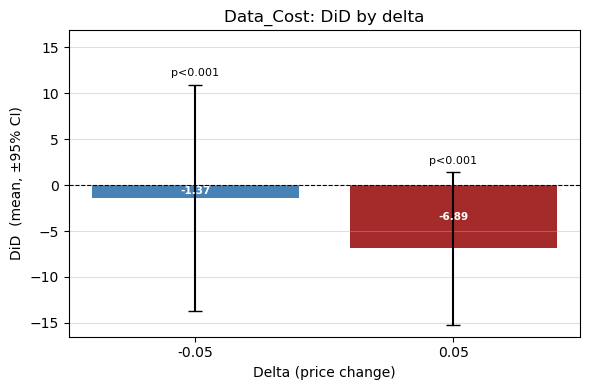


  Avg_Relevance   (quality/rate metric)
n groups with valid did: 957  (missing: 0)
 delta   n   mean   std  cdf0     p5    q25  median  q75   p95    p_t  p_trim  p_wilcox
 -0.05 319  0.005 0.074 0.480 -0.117 -0.033     0.0 0.05 0.133 0.2365  0.0373    0.1463
  0.05 319 -0.003 0.111 0.536 -0.150 -0.050     0.0 0.05 0.150 0.6505  0.9466    0.8232


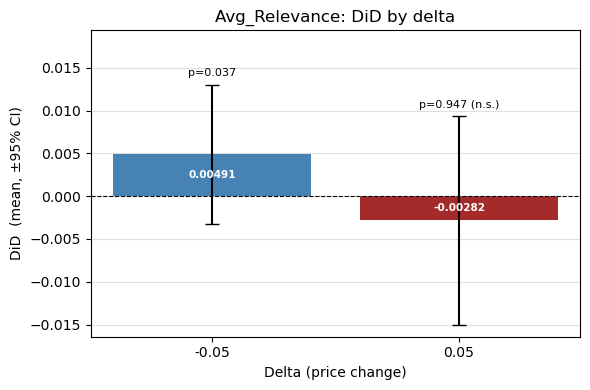


  Avg_Relevance_Percentile   (quality/rate metric)
n groups with valid did: 957  (missing: 0)
 delta   n  mean   std  cdf0     p5   q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 319 0.190 1.921 0.464 -3.497 -0.60   0.083 0.967 3.785 0.0782  0.0011    0.0501
  0.05 319 0.196 1.890 0.458 -2.978 -0.55   0.117 0.875 3.887 0.0653  0.0049    0.0581


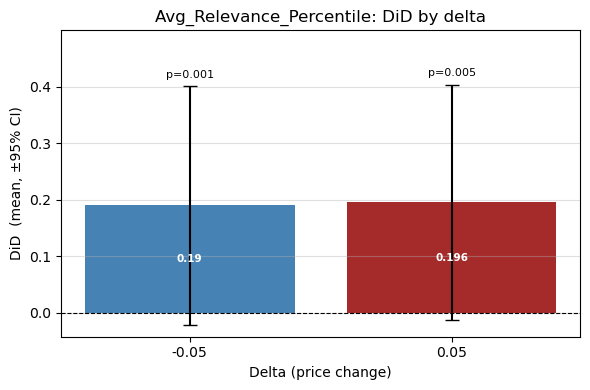


  Avg_Value_Percentile   (quality/rate metric)
n groups with valid did: 651  (missing: 54)
 delta   n  mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 207 0.186 1.075 0.464 -1.554 -0.360   0.033 0.675 1.931 0.0139  0.0009    0.0304
  0.05 209 0.164 1.303 0.455 -1.717 -0.433   0.117 0.767 2.027 0.0704  0.0052    0.0454


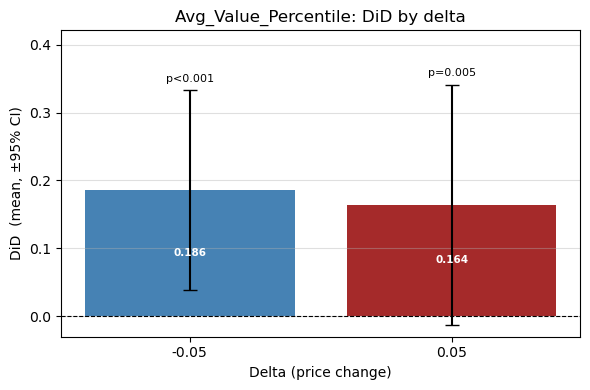


  Avg_Value_Score   (quality/rate metric)
n groups with valid did: 651  (missing: 54)
 delta   n  mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 207 0.125 0.737 0.483 -0.808 -0.333   0.033 0.367 1.303 0.0155  0.0046    0.0396
  0.05 209 0.066 1.070 0.517 -1.167 -0.333   0.000 0.500 1.500 0.3741  0.0996    0.2662


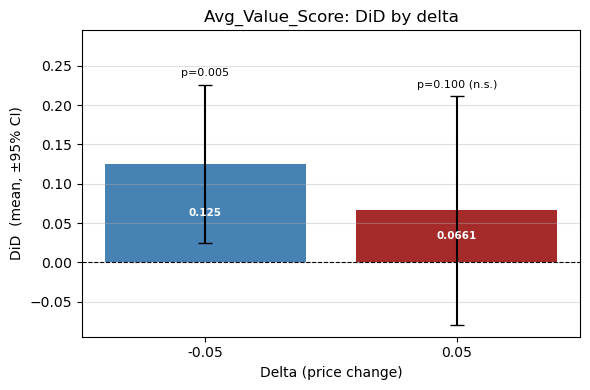


  Effective_Impression_Count   (volume metric)
n groups with valid did: 957  (missing: 0)
 delta   n       mean        std  cdf0          p5        q25  median       q75        p95    p_t  p_trim  p_wilcox
 -0.05 319  13243.608 311564.674 0.282  -53365.633     -3.167  1798.0 25111.500 214901.800 0.4490     0.0    0.0000
  0.05 319 -38702.168 213506.817 0.624 -218576.300 -12712.417    -5.0   968.167  45293.467 0.0014     0.0    0.0001

 delta   n  mean(did)/mean(lvl)  trim(did)/trim(lvl)  median(did)/median(lvl)  sum(did)/sum(lvl)  median(did)/mean(lvl)
 -0.05 319               0.2066               0.9315                   1.6385             0.2066                 0.0281
  0.05 319              -0.6038              -0.5350                  -0.0046            -0.6038                -0.0001


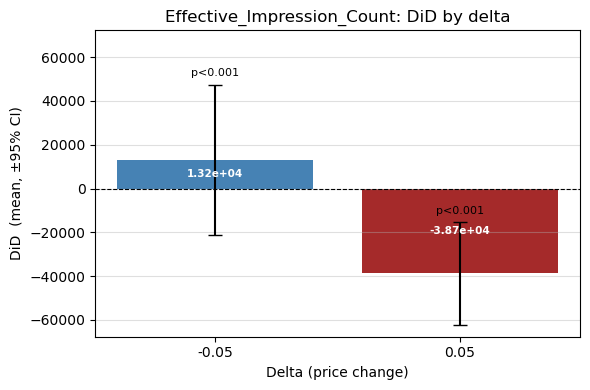


  Match_Pct   (quality/rate metric)
n groups with valid did: 661  (missing: 53)
 delta   n   mean   std  cdf0     p5  q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 211 -0.001 0.025 0.417 -0.019 -0.0     0.0 0.001 0.007 0.7338  0.0000    0.0017
  0.05 212 -0.002 0.020 0.566 -0.014 -0.0    -0.0 0.000 0.004 0.1243  0.0043    0.1525


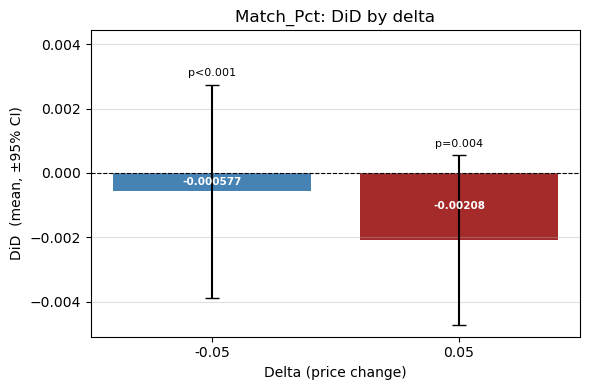


  Match_Pct_Percentile   (quality/rate metric)
n groups with valid did: 661  (missing: 53)
 delta   n  mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 211 3.514 11.551 0.389 -14.465 -0.508   0.483 7.754 25.494 0.0000  0.0000    0.0000
  0.05 212 0.541  9.969 0.533 -15.296 -3.121  -0.000 3.117 19.758 0.4317  0.6704    0.8168


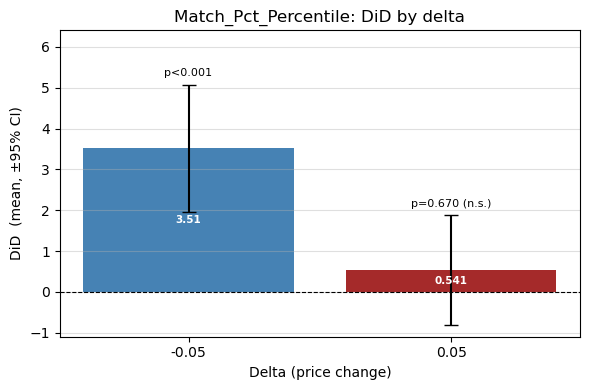


  Paid_Pct   (quality/rate metric)
n groups with valid did: 661  (missing: 53)
 delta   n   mean    std  cdf0      p5     q25  median    q75    p95   p_t  p_trim  p_wilcox
 -0.05 211  2.076 38.217 0.431 -64.217 -19.833   7.017 27.258 58.417 0.432  0.0814    0.1740
  0.05 212 -5.645 30.084 0.613 -51.597 -22.063  -6.617  7.721 50.301 0.007  0.0000    0.0002


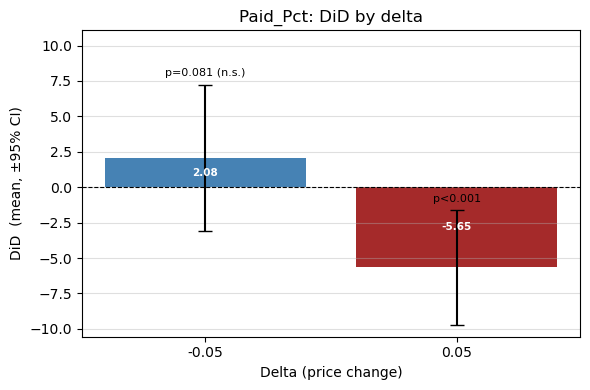


  Paid_Pct_Percentile   (quality/rate metric)
n groups with valid did: 661  (missing: 53)
 delta   n   mean   std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 211  0.507 9.246 0.431 -15.783 -4.875   2.033 6.542 13.000 0.4276  0.0405    0.1242
  0.05 212 -1.379 7.495 0.627 -12.899 -5.258  -1.792 1.688 12.598 0.0081  0.0000    0.0001


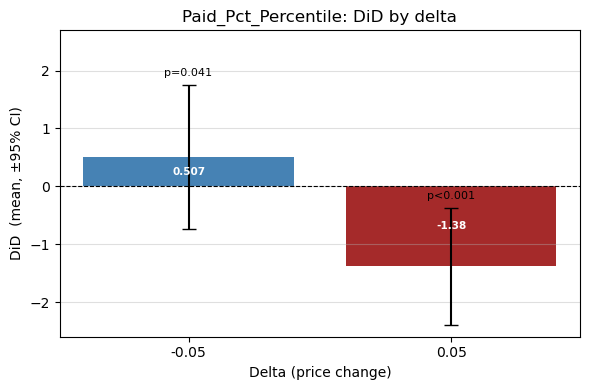

In [35]:
bucket_results = {}
for y in Y_VARS:
    bucket_results[y] = analyze_metric_by_bucket(y)

## ATE estimation — Route 1: bucket-weighted ATT

Same design as `TTD3_Pricing.ipynb`'s ATE section: bucket ATT estimated three
ways (mean/trim10%/median), population-weighted by the true universe's
bucket composition (`rev_pool_geo`, Global sharethis), bootstrap 95% CIs, and
a per-bucket "recommended delta" (including "do nothing" as a fixed
reference). For volume metrics this also extrapolates to a total
portfolio-dollar/count figure against a panel baseline; for quality/rate
metrics the ATE stays in native per-segment units (no portfolio
extrapolation — a "total percentile points across the portfolio" isn't a
meaningful quantity).

In [36]:
# ── universe bucket weights (revenue-based, shared across all metrics) ───────
rev_pool_geo = rev_pool.copy()
rev_pool_geo['geo'] = rev_pool_geo['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))
total_rev_all = rev_pool_geo['revenue'].sum()

bkts = list(reversed(BUCKET_ORDER))
st_global_universe = rev_pool_geo[
    (rev_pool_geo['geo'] == 'Global') & (rev_pool_geo['Third_Party_Data_Provider_Id'] == 'sharethis')
]
n_by_bkt = st_global_universe.groupby('bucket').size().reindex(bkts).fillna(0).astype(int)
seg_wt   = n_by_bkt / n_by_bkt.sum()
n_univ   = int(n_by_bkt.sum())

print(f"n_univ = {n_univ:,}")
print(pd.DataFrame({'n_segs': n_by_bkt, 'seg_wt': seg_wt.round(4)}))


def panel_baseline(y):
    """Mean weekly total `y` across the pre-period panel (Global sharethis,
    same window as test/did) -- the extrapolation baseline for volume
    metrics only."""
    pre_weeks_global = dat1[
        (dat1['Third_Party_Data_Provider_Id'] == 'sharethis') &
        (dat1['geo'] == 'Global') &
        (dat1['post'] == 0) &
        (dat1['Week_Start_Date'] > test_df_start)
    ]
    weekly_agg = pre_weeks_global.groupby('Week_Start_Date')[y].sum()
    return apply_estimator(weekly_agg.values, 'mean')

n_univ = 1,020
        n_segs  seg_wt
bucket                
1000+       14  0.0137
100+        82  0.0804
10+        233  0.2284
1+         190  0.1863
0+         501  0.4912


In [37]:
N_BOOT = 1000
TRIM   = 0.10
RNG    = np.random.default_rng(42)


def att_table(did_sub, estimator, bkts, deltas_nz, trim=TRIM):
    rows = {}
    for b in bkts:
        rows[b] = {}
        for d in deltas_nz:
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == d)]['did'].dropna().values
            rows[b][d] = apply_estimator(vals, estimator, trim) if len(vals) > 0 else np.nan
    return pd.DataFrame(rows).T.reindex(bkts)


def best_delta_for_bucket(tbl, b, deltas_nz):
    """'do nothing' (delta=0, fixed ATT=0) vs. each treated delta's ATT at
    this bucket. A NaN cell (no data for that bucket x delta) is treated as
    -inf so it's never spuriously picked as 'best'."""
    candidates = {0.0: 0.0}
    for d in deltas_nz:
        v = tbl.loc[b, d]
        candidates[d] = v if pd.notna(v) else -np.inf
    best_d = max(candidates, key=candidates.get)
    return best_d, (candidates[best_d] if np.isfinite(candidates[best_d]) else np.nan)


def boot_ate(did_sub, seg_wt, bkts, delta, n_boot, rng, fn):
    samples = []
    for _ in range(n_boot):
        ate_b = 0.0
        for b in bkts:
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == delta)]['did'].dropna().values
            if len(vals) == 0: continue
            ate_b += seg_wt[b] * fn(rng.choice(vals, size=len(vals), replace=True))
        samples.append(ate_b)
    return np.percentile(samples, [2.5, 97.5])


def boot_att_overall(did_sub, delta, n_boot, rng, fn):
    vals = did_sub[did_sub['delta'] == delta]['did'].dropna().values
    if len(vals) == 0:
        return (np.nan, np.nan)
    boots = [fn(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])


def boot_recommended_ate(did_sub, seg_wt, bkts, recommended_delta, n_boot, rng, fn):
    samples = []
    for _ in range(n_boot):
        ate_b = 0.0
        for b in bkts:
            d = recommended_delta[b]
            if d == 0.0:
                continue
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == d)]['did'].dropna().values
            if len(vals) == 0: continue
            ate_b += seg_wt[b] * fn(rng.choice(vals, size=len(vals), replace=True))
        samples.append(ate_b)
    return np.percentile(samples, [2.5, 97.5])


def ate_from_att(att_tbl, seg_wt, deltas_nz):
    return (att_tbl[deltas_nz].T * seg_wt).T.sum(skipna=False)

In [38]:
def plot_recommended_by_bucket(y, rec_df, seg_wt, deltas_nz):
    action_colors = {d: ('tomato' if d > 0 else 'steelblue') for d in deltas_nz}
    action_colors[0.0] = '#AAAAAA'
    plot_buckets = BUCKET_ORDER  # ascending low -> high revenue

    fig, ax = plt.subplots(figsize=(9, 0.55 * len(plot_buckets) + 1))
    for i, b in enumerate(plot_buckets):
        d = rec_df.loc[b, 'recommended_delta']
        ax.barh(i, seg_wt[b], color=action_colors[d], alpha=0.85)
        action_label = 'no change' if d == 0.0 else f'delta={d:+.2f}'
        v = rec_df.loc[b, 'att_at_recommended']
        label = f"{action_label}  (median ATT={v:+.4g}/seg/wk)" if pd.notna(v) else action_label
        ax.text(seg_wt[b] + seg_wt.max() * 0.02, i, label, va='center', fontsize=8)
    ax.set_yticks(range(len(plot_buckets))); ax.set_yticklabels(plot_buckets)
    ax.set_xlabel('Population weight (seg_wt)')
    ax.set_title(f"{y}: Recommended treatment by bucket, using median ATT")
    ax.set_xlim(0, seg_wt.max() * 1.7)
    ax.grid(axis='x', alpha=0.3)
    legend_deltas = [0.0] + deltas_nz
    ax.legend(
        [plt.Rectangle((0, 0), 1, 1, color=action_colors[d]) for d in legend_deltas],
        ['no change (0)' if d == 0.0 else f'delta={d:+.2f}' for d in legend_deltas],
        fontsize=8, loc='lower right'
    )
    plt.tight_layout()
    plt.show()


def plot_att_ate_comparison(y, is_volume, att_trim_overall, ate_trim, att_median_overall, ate_median,
                             ci, deltas_nz, n_univ, baseline, recommended_ate):
    x_pos = np.arange(len(deltas_nz))
    xlabels = [f'{d:+.2f}' for d in deltas_nz]
    bw = 0.2
    plot_ests = [
        ('ATT trim',   'trim',   'att', att_trim_overall,   'steelblue', -1.5),
        ('ATE trim',   'trim',   'ate', ate_trim,            '#E07B39',  -0.5),
        ('ATT median', 'median', 'att', att_median_overall,  '#5A9E6F',   0.5),
        ('ATE median', 'median', 'ate', ate_median,          '#BE4A6A',   1.5),
    ]
    n_panels = 2 if is_volume else 1
    fig, axes = plt.subplots(1, n_panels, figsize=(6.5 * n_panels, 4.2), squeeze=False)
    axes = axes[0]

    def _panel(ax, scale, ylabel, rec_line_val, title):
        for label, est, kind, series, col, offset in plot_ests:
            vals = [series.get(d, float('nan')) * scale for d in deltas_nz]
            cis  = [ci.get((est, kind, d), (np.nan, np.nan)) for d in deltas_nz]
            lo_  = [(series.get(d, float('nan')) - c[0]) * scale for d, c in zip(deltas_nz, cis)]
            hi_  = [(c[1] - series.get(d, float('nan'))) * scale for d, c in zip(deltas_nz, cis)]
            xpos = x_pos + offset * bw
            ax.bar(xpos, vals, bw, label=label, color=col, alpha=0.82, zorder=3)
            ax.errorbar(xpos, vals, yerr=[lo_, hi_], fmt='none', color='black', capsize=3, lw=1, zorder=4)
        ax.axhline(0, color='#333', lw=0.8, ls='--')
        ax.axhline(rec_line_val, color='purple', lw=1.5, ls=':', zorder=5, label='Recommended ATE')
        ax.set_xticks(x_pos); ax.set_xticklabels(xlabels)
        ax.set_xlabel('Delta (price shift)'); ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=7.5, ncol=2); ax.grid(axis='y', alpha=0.3)

    if is_volume:
        rec_tot, _, rec_rel = relative_did(recommended_ate, scale=n_univ, baseline=baseline)
        _panel(axes[0], n_univ, f'total {y} / week', rec_tot, f'{y}: ATT vs ATE -- total/week')
        _panel(axes[1], n_univ / baseline, 'Derived relative (/ panel baseline)', rec_rel,
               f'{y}: Derived relative [baseline={baseline:,.2f}]')
    else:
        _panel(axes[0], 1.0, f'{y}  (pts/seg/wk)', recommended_ate,
               f'{y}: ATT vs ATE  (per-segment units, no portfolio extrapolation)')

    plt.tight_layout()
    plt.show()

In [39]:
def run_ate_for_metric(y, seg_wt, bkts, n_univ):
    is_volume = y in VOLUME_METRICS
    print(f"\n{'='*78}\n  METRIC: {y}   ({'volume' if is_volume else 'quality/rate'} metric)\n{'='*78}")

    d = attach_bucket(build_did_for_metric(y))
    did_sub = d[d['bucket'].notna()].copy()
    deltas_nz = sorted([dd for dd in did_sub['delta'].unique() if dd != 0.0])

    att_mean   = att_table(did_sub, 'mean',   bkts, deltas_nz)
    att_trim   = att_table(did_sub, 'trim',   bkts, deltas_nz)
    att_median = att_table(did_sub, 'median', bkts, deltas_nz)

    print(f"\nATT by bucket x delta  [{y} / seg / wk]")
    print(f"  {'':12s}" + ''.join(f"  delta={dd:+.2f}" for dd in deltas_nz))
    for b in bkts:
        vals_sub = did_sub[did_sub['bucket'] == b]
        print(f"  {b:<10s}  (seg_wt={seg_wt[b]:.4f})")
        for label, tbl in [('mean  ', att_mean), (f'trim{int(TRIM*100)}%', att_trim), ('median', att_median)]:
            row = f"    {label}  "
            for dd in deltas_nz:
                v = tbl.loc[b, dd]
                n = len(vals_sub[vals_sub['delta'] == dd]['did'].dropna())
                row += f"  {v:>+10.4f} (n={n})  " if pd.notna(v) else f"  {'n/a':>10s} (n={n})  "
            print(row)

    def recommend(att_tbl):
        rows = []
        for b in bkts:
            best_d, best_v = best_delta_for_bucket(att_tbl, b, deltas_nz)
            rows.append({'bucket': b, 'recommended_delta': best_d, 'att_at_recommended': best_v})
        return pd.DataFrame(rows).set_index('bucket')

    rec_df_median = recommend(att_median)
    rec_df_trim   = recommend(att_trim)
    rec_df_mean   = recommend(att_mean)
    rec_df = rec_df_median.copy()
    rec_df['seg_wt']    = seg_wt.reindex(rec_df.index)
    rec_df['best@trim'] = rec_df_trim['recommended_delta']
    rec_df['best@mean'] = rec_df_mean['recommended_delta']
    rec_df['estimators_agree'] = (
        (rec_df['recommended_delta'] == rec_df['best@trim']) & (rec_df['recommended_delta'] == rec_df['best@mean'])
    )
    recommended_delta      = rec_df['recommended_delta'].to_dict()
    recommended_delta_trim = rec_df_trim['recommended_delta'].to_dict()

    print(f"\nRecommended delta by bucket  ('do nothing' = fixed ATT 0, compared against both treated deltas):")
    print(rec_df[['seg_wt', 'recommended_delta', 'att_at_recommended', 'best@trim', 'best@mean', 'estimators_agree']].to_string())

    recommended_ate      = (rec_df_median['att_at_recommended'].fillna(0) * seg_wt.reindex(rec_df_median.index)).sum()
    recommended_ate_trim  = (rec_df_trim['att_at_recommended'].fillna(0)   * seg_wt.reindex(rec_df_trim.index)).sum()

    ci = {}
    for dd in deltas_nz:
        for est_name in ['trim', 'median']:
            fn = (lambda v, e=est_name: apply_estimator(v, e, TRIM))
            ci[(est_name, 'att', dd)] = boot_att_overall(did_sub, dd, N_BOOT, RNG, fn)
            ci[(est_name, 'ate', dd)] = boot_ate(did_sub, seg_wt, bkts, dd, N_BOOT, RNG, fn)
    rec_ci = boot_recommended_ate(did_sub, seg_wt, bkts, recommended_delta, N_BOOT, RNG,
                                   lambda v: apply_estimator(v, 'median', TRIM))
    rec_ci_trim = boot_recommended_ate(did_sub, seg_wt, bkts, recommended_delta_trim, N_BOOT, RNG,
                                        lambda v: apply_estimator(v, 'trim', TRIM))

    ate_trim   = ate_from_att(att_trim,   seg_wt, deltas_nz)
    ate_median = ate_from_att(att_median, seg_wt, deltas_nz)
    att_trim_overall   = did_sub.groupby('delta')['did'].apply(lambda v: apply_estimator(v.dropna().values, 'trim'))
    att_median_overall = did_sub.groupby('delta')['did'].apply(lambda v: apply_estimator(v.dropna().values, 'median'))

    baseline = panel_baseline(y) if is_volume else None
    if is_volume:
        def _fmt_cell(v, ci_pair):
            if v is None or pd.isna(v): return 'n/a'
            tot, _, rel = relative_did(v, scale=n_univ, baseline=baseline)
            if ci_pair is None:
                return f"{tot:+,.2f}  (rel {rel:+.3f})"
            lo, hi = ci_pair[0] * n_univ, ci_pair[1] * n_univ
            return f"{tot:+,.2f}  (rel {rel:+.3f})  CI[{lo:+,.2f}, {hi:+,.2f}]"
        print(f"\nBaseline (total panel weekly {y}): {baseline:,.2f}")
    else:
        def _fmt_cell(v, ci_pair):
            if v is None or pd.isna(v): return 'n/a'
            if ci_pair is None:
                return f"{v:+.4f} pts/seg/wk"
            return f"{v:+.4f} pts/seg/wk  CI[{ci_pair[0]:+.4f}, {ci_pair[1]:+.4f}]"

    summary_rows = [
        ('ATT trimmed mean', 'trim',   'att', att_trim_overall,   None,                 None),
        ('ATE trimmed mean', 'trim',   'ate', ate_trim,           recommended_ate_trim, rec_ci_trim),
        ('ATT median',       'median', 'att', att_median_overall, None,                 None),
        ('ATE median',       'median', 'ate', ate_median,         recommended_ate,      rec_ci),
    ]
    att_rows, ate_rows = {}, {}
    for label, est, kind, series, rec_val, rec_ci_pair in summary_rows:
        row = {}
        for dd in deltas_nz:
            v = series.get(dd, float('nan'))
            row[f'delta={dd:+.2f}'] = _fmt_cell(v, ci.get((est, kind, dd)))
        if kind == 'att':
            att_rows[label] = row
        else:
            row['Recommended'] = _fmt_cell(rec_val, rec_ci_pair)
            ate_rows[label] = row
    att_df = pd.DataFrame(att_rows)
    ate_df = pd.DataFrame(ate_rows)
    pd.set_option('display.width', 200)

    print(f"\nATT summary  [{'$' if is_volume else 'pts'}, 95% CI, n_boot={N_BOOT}, trim={int(TRIM*100)}%]")
    print(att_df.to_string())
    print(f"\nATE summary  [{'$' if is_volume else 'pts'}, 95% CI, n_boot={N_BOOT}, trim={int(TRIM*100)}%]")
    print(ate_df.to_string())

    plot_recommended_by_bucket(y, rec_df, seg_wt, deltas_nz)
    plot_att_ate_comparison(y, is_volume, att_trim_overall, ate_trim, att_median_overall, ate_median,
                            ci, deltas_nz, n_univ, baseline, recommended_ate)

    return dict(did_sub=did_sub, rec_df=rec_df, att_mean=att_mean, att_trim=att_trim, att_median=att_median,
                recommended_ate=recommended_ate, recommended_ate_trim=recommended_ate_trim, baseline=baseline)


  METRIC: Data_Cost   (volume metric)

ATT by bucket x delta  [Data_Cost / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean       -433.4690 (n=5)     -262.4910 (n=5)  
    trim10%     -433.4690 (n=5)     -262.4910 (n=5)  
    median      -64.7033 (n=5)       -1.1883 (n=5)  
  100+        (seg_wt=0.0804)
    mean        +35.1960 (n=27)      -31.5440 (n=27)  
    trim10%      +29.8932 (n=27)      -27.6923 (n=27)  
    median      +17.4317 (n=27)       -9.0950 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +7.2006 (n=77)       +0.4669 (n=77)  
    trim10%       +4.9606 (n=77)       -1.0739 (n=77)  
    median       +3.4633 (n=77)       -1.4867 (n=77)  
  1+          (seg_wt=0.1863)
    mean         +2.8537 (n=53)       -0.0483 (n=53)  
    trim10%       +1.3327 (n=53)       -0.0650 (n=53)  
    median       +0.6183 (n=53)       -0.0533 (n=53)  
  0+          (seg_wt=0.4912)
    mean         +0.4665 (n=157)       -0.4373 (n=157)  
    trim

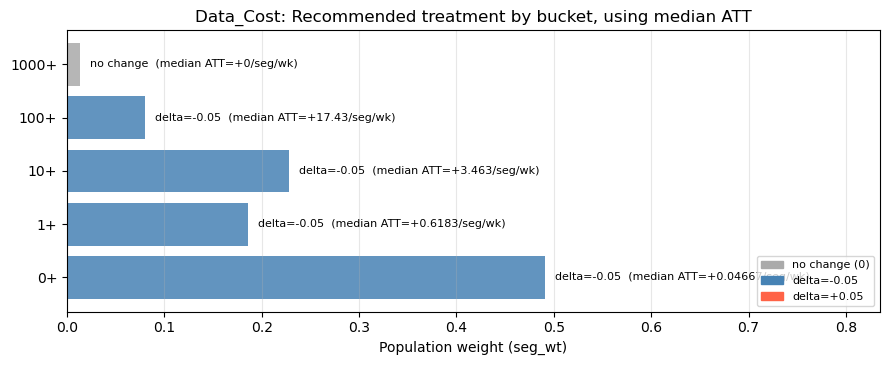

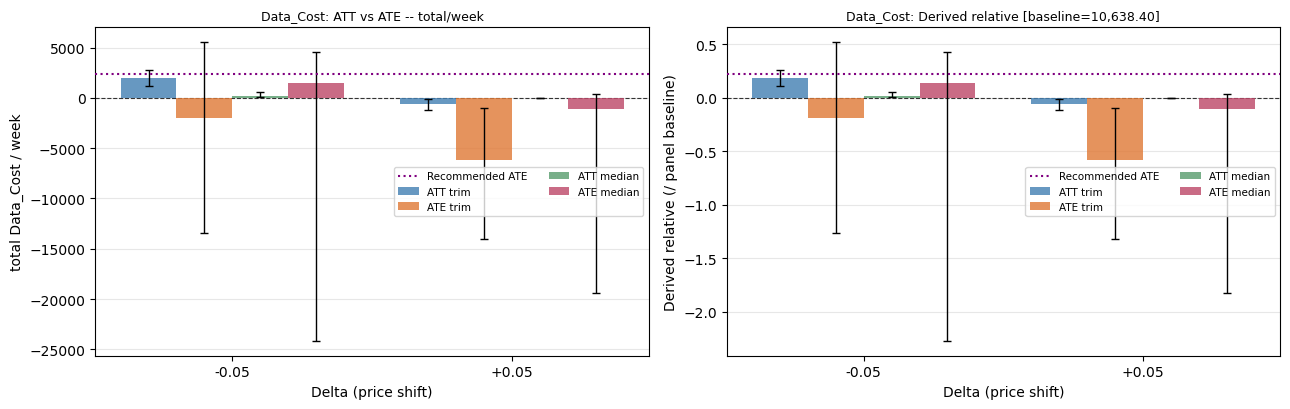


  METRIC: Avg_Relevance   (quality/rate metric)

ATT by bucket x delta  [Avg_Relevance / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         -0.0033 (n=5)       -0.0067 (n=5)  
    trim10%       -0.0033 (n=5)       -0.0067 (n=5)  
    median       +0.0167 (n=5)       +0.0167 (n=5)  
  100+        (seg_wt=0.0804)
    mean         +0.0111 (n=27)       +0.0086 (n=27)  
    trim10%       +0.0080 (n=27)       +0.0087 (n=27)  
    median       +0.0000 (n=27)       +0.0167 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +0.0074 (n=77)       -0.0024 (n=77)  
    trim10%       +0.0106 (n=77)       +0.0021 (n=77)  
    median       +0.0167 (n=77)       +0.0000 (n=77)  
  1+          (seg_wt=0.1863)
    mean         +0.0160 (n=53)       +0.0047 (n=53)  
    trim10%       +0.0143 (n=53)       +0.0023 (n=53)  
    median       +0.0167 (n=53)       -0.0167 (n=53)  
  0+          (seg_wt=0.4912)
    mean         -0.0008 (n=157)       -0.0074 (n=1

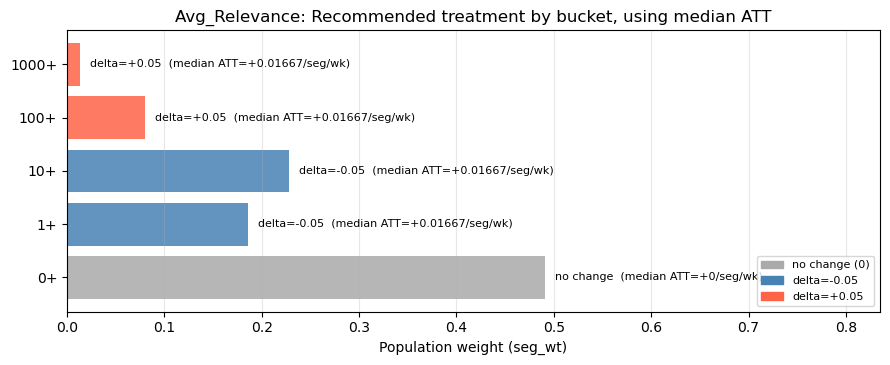

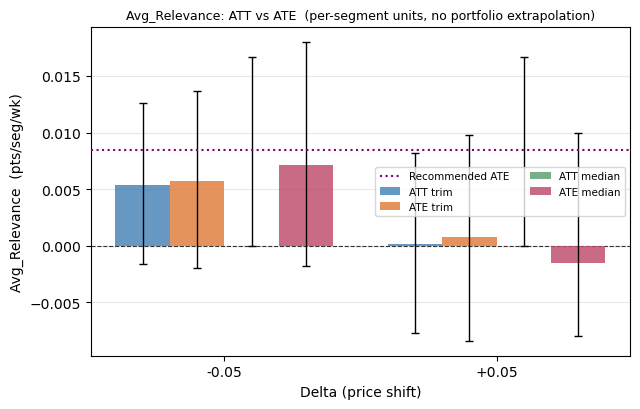


  METRIC: Avg_Relevance_Percentile   (quality/rate metric)

ATT by bucket x delta  [Avg_Relevance_Percentile / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         -1.0233 (n=5)       +0.6300 (n=5)  
    trim10%       -1.0233 (n=5)       +0.6300 (n=5)  
    median       -0.4000 (n=5)       +0.1333 (n=5)  
  100+        (seg_wt=0.0804)
    mean         -0.0494 (n=27)       +0.3272 (n=27)  
    trim10%       -0.0594 (n=27)       +0.3493 (n=27)  
    median       -0.1167 (n=27)       +0.1167 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +0.4494 (n=77)       +0.4879 (n=77)  
    trim10%       +0.5008 (n=77)       +0.5058 (n=77)  
    median       +0.2500 (n=77)       +0.4167 (n=77)  
  1+          (seg_wt=0.1863)
    mean         +0.3535 (n=53)       +0.0912 (n=53)  
    trim10%       +0.2880 (n=53)       +0.1457 (n=53)  
    median       +0.2667 (n=53)       +0.2500 (n=53)  
  0+          (seg_wt=0.4912)
    mean         +0.0880 (n=1

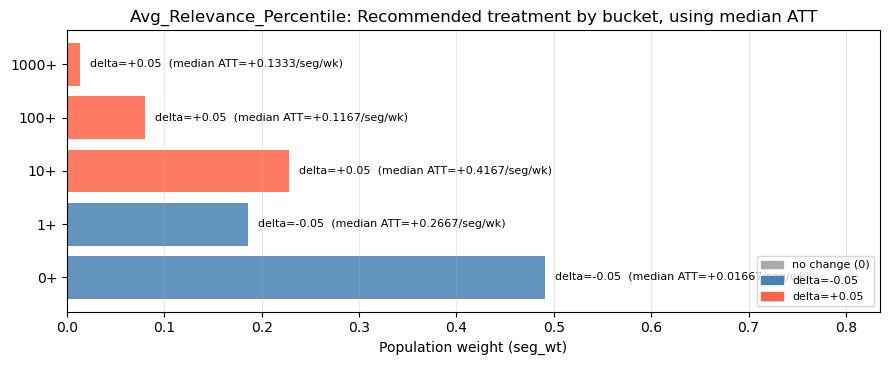

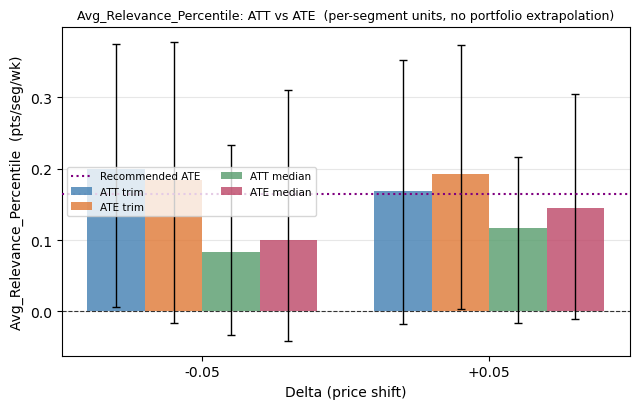


  METRIC: Avg_Value_Percentile   (quality/rate metric)

ATT by bucket x delta  [Avg_Value_Percentile / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         +0.1733 (n=5)       +0.3233 (n=5)  
    trim10%       +0.1733 (n=5)       +0.3233 (n=5)  
    median       -0.0667 (n=5)       +0.2167 (n=5)  
  100+        (seg_wt=0.0804)
    mean         +0.0220 (n=27)       +0.0528 (n=27)  
    trim10%       -0.0148 (n=27)       +0.0809 (n=27)  
    median       -0.1500 (n=27)       +0.1000 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +0.2733 (n=76)       +0.2060 (n=76)  
    trim10%       +0.3015 (n=76)       +0.2447 (n=76)  
    median       +0.3083 (n=76)       +0.2250 (n=76)  
  1+          (seg_wt=0.1863)
    mean         +0.1357 (n=41)       +0.1567 (n=41)  
    trim10%       +0.0031 (n=41)       -0.0316 (n=41)  
    median       +0.0000 (n=41)       -0.1167 (n=41)  
  0+          (seg_wt=0.4912)
    mean         +0.1839 (n=58)      

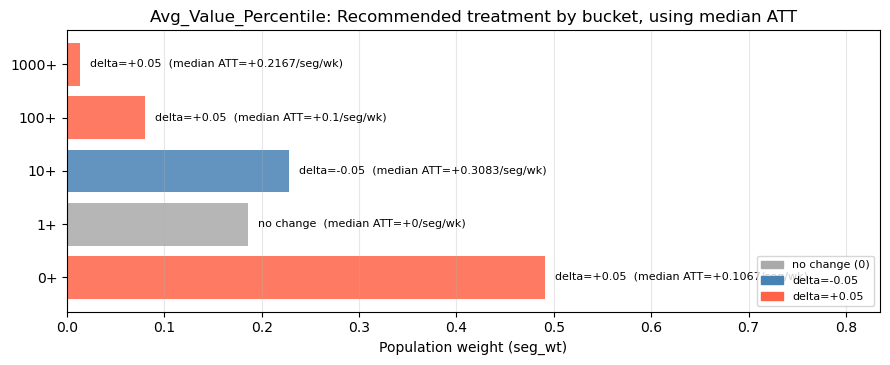

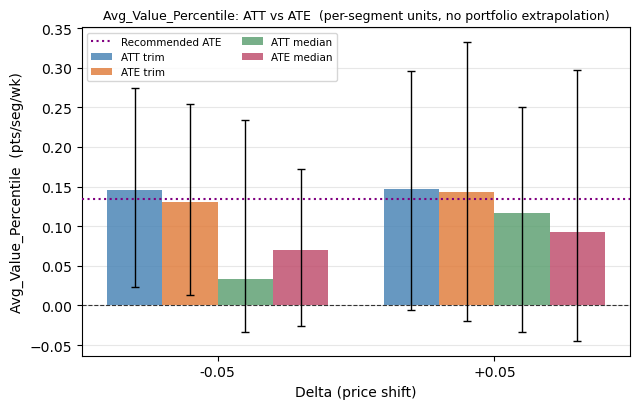


  METRIC: Avg_Value_Score   (quality/rate metric)

ATT by bucket x delta  [Avg_Value_Score / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         +0.0667 (n=5)       +0.1000 (n=5)  
    trim10%       +0.0667 (n=5)       +0.1000 (n=5)  
    median       -0.1667 (n=5)       +0.1667 (n=5)  
  100+        (seg_wt=0.0804)
    mean         +0.1012 (n=27)       +0.0333 (n=27)  
    trim10%       +0.0899 (n=27)       +0.0652 (n=27)  
    median       +0.1667 (n=27)       +0.1667 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +0.1116 (n=76)       +0.0511 (n=76)  
    trim10%       +0.1019 (n=76)       +0.0368 (n=76)  
    median       +0.1667 (n=76)       +0.0000 (n=76)  
  1+          (seg_wt=0.1863)
    mean         +0.2764 (n=41)       +0.3110 (n=41)  
    trim10%       +0.1273 (n=41)       +0.1869 (n=41)  
    median       +0.1667 (n=41)       +0.0000 (n=41)  
  0+          (seg_wt=0.4912)
    mean         +0.0529 (n=58)       -0.0703 (

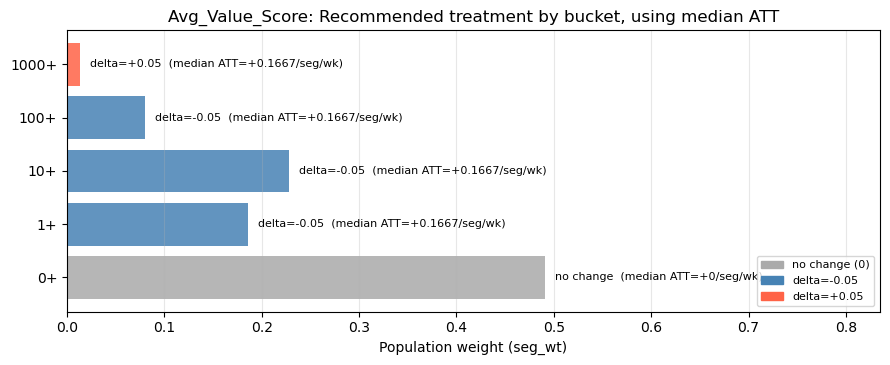

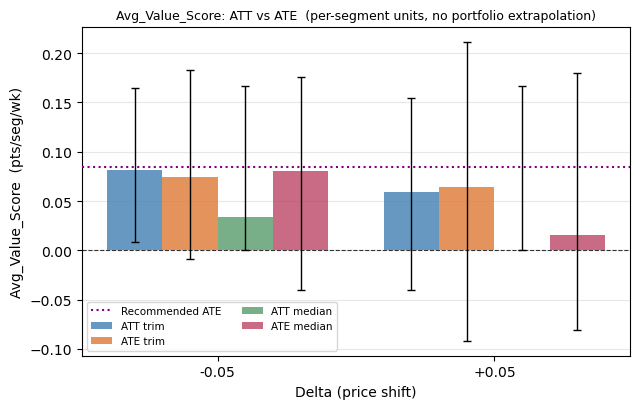


  METRIC: Effective_Impression_Count   (volume metric)

ATT by bucket x delta  [Effective_Impression_Count / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean      -1200468.0667 (n=5)    -786477.7333 (n=5)  
    trim10%    -1200468.0667 (n=5)    -786477.7333 (n=5)  
    median    -580750.8333 (n=5)    -660726.0000 (n=5)  
  100+        (seg_wt=0.0804)
    mean      +233487.6728 (n=27)    -166447.5309 (n=27)  
    trim10%    +194287.0725 (n=27)    -162903.1449 (n=27)  
    median    +101489.0000 (n=27)    -71460.8333 (n=27)  
  10+         (seg_wt=0.2284)
    mean      +47938.8593 (n=77)    -27287.4286 (n=77)  
    trim10%    +37224.2354 (n=77)    -21574.4312 (n=77)  
    median    +23436.5000 (n=77)    -19362.5000 (n=77)  
  1+          (seg_wt=0.1863)
    mean      +18388.6164 (n=53)    +1844.9623 (n=53)  
    trim10%    +9000.0698 (n=53)    -1392.5155 (n=53)  
    median    +3282.6667 (n=53)    -1002.5000 (n=53)  
  0+          (seg_wt=0.4912)

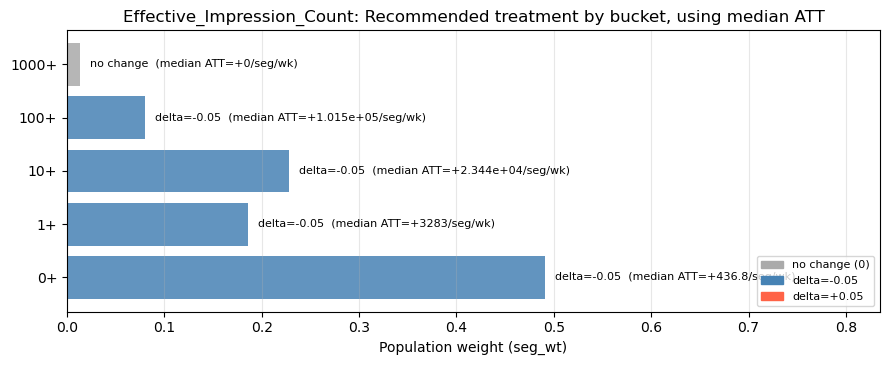

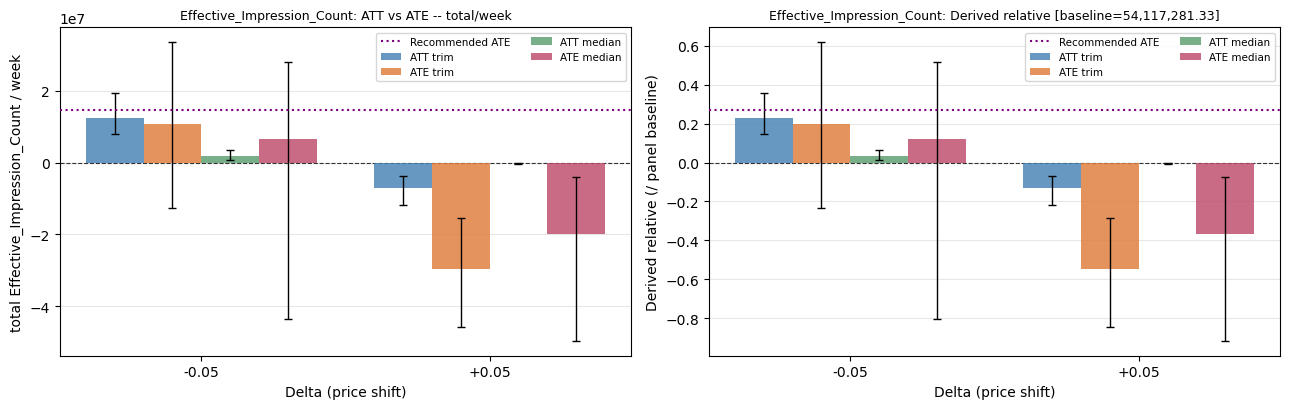


  METRIC: Match_Pct   (quality/rate metric)

ATT by bucket x delta  [Match_Pct / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         -0.0044 (n=5)       -0.0063 (n=5)  
    trim10%       -0.0044 (n=5)       -0.0063 (n=5)  
    median       -0.0116 (n=5)       -0.0040 (n=5)  
  100+        (seg_wt=0.0804)
    mean         +0.0035 (n=27)       -0.0088 (n=27)  
    trim10%       -0.0009 (n=27)       -0.0071 (n=27)  
    median       +0.0012 (n=27)       -0.0009 (n=27)  
  10+         (seg_wt=0.2284)
    mean         -0.0030 (n=76)       -0.0020 (n=76)  
    trim10%       +0.0000 (n=76)       -0.0001 (n=76)  
    median       +0.0003 (n=76)       +0.0000 (n=76)  
  1+          (seg_wt=0.1863)
    mean         +0.0002 (n=41)       -0.0005 (n=42)  
    trim10%       +0.0004 (n=41)       -0.0000 (n=42)  
    median       +0.0001 (n=41)       +0.0000 (n=42)  
  0+          (seg_wt=0.4912)
    mean         +0.0004 (n=62)       -0.0000 (n=62)  
    

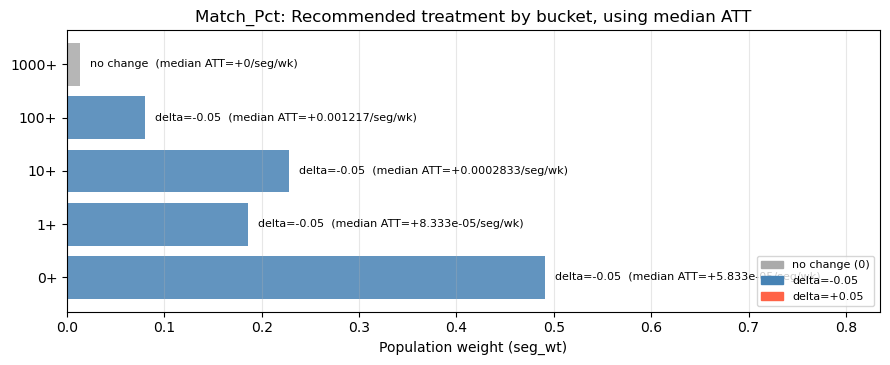

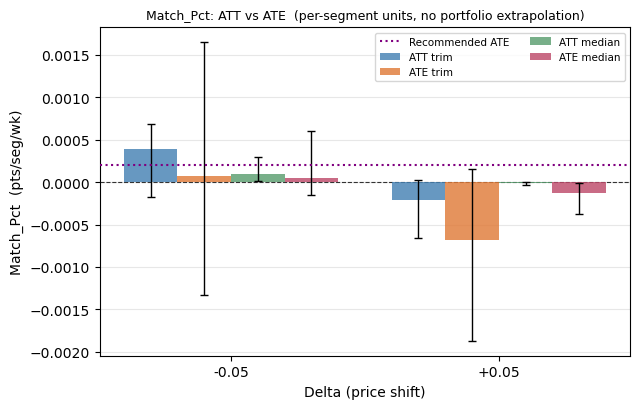


  METRIC: Match_Pct_Percentile   (quality/rate metric)

ATT by bucket x delta  [Match_Pct_Percentile / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         +0.8867 (n=5)       +1.0333 (n=5)  
    trim10%       +0.8867 (n=5)       +1.0333 (n=5)  
    median       -0.1000 (n=5)       -0.1667 (n=5)  
  100+        (seg_wt=0.0804)
    mean         +0.3420 (n=27)       +0.5642 (n=27)  
    trim10%       -0.0094 (n=27)       -0.0993 (n=27)  
    median       +0.0667 (n=27)       -0.1500 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +2.0700 (n=76)       -0.5659 (n=76)  
    trim10%       +1.6438 (n=76)       -0.6435 (n=76)  
    median       +0.3583 (n=76)       -0.0083 (n=76)  
  1+          (seg_wt=0.1863)
    mean         +4.3908 (n=41)       -0.7098 (n=42)  
    trim10%       +3.6815 (n=41)       -0.6533 (n=42)  
    median       +2.0833 (n=41)       +0.0000 (n=42)  
  0+          (seg_wt=0.4912)
    mean         +6.2970 (n=62)      

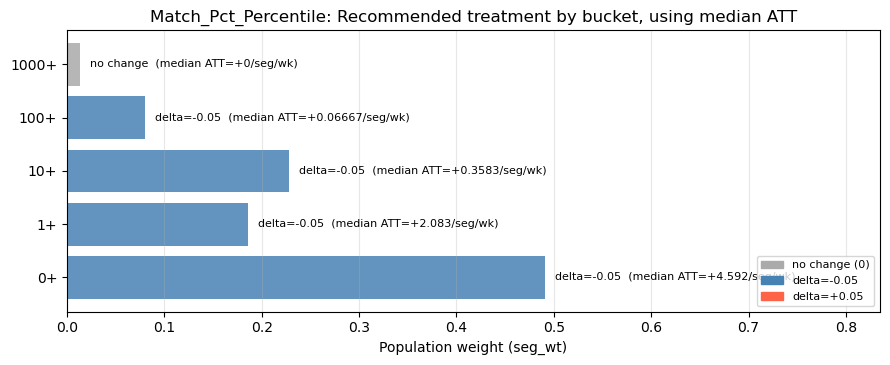

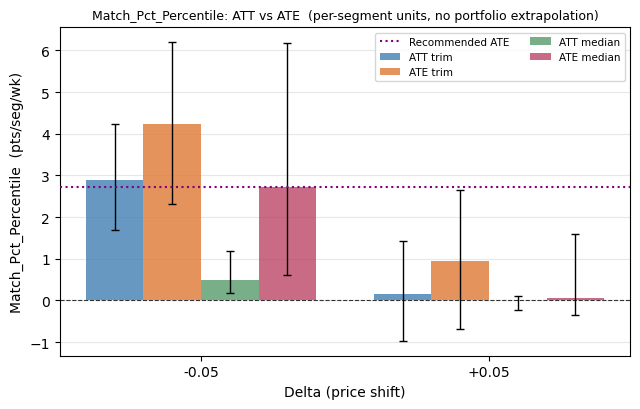


  METRIC: Paid_Pct   (quality/rate metric)

ATT by bucket x delta  [Paid_Pct / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean        -10.0100 (n=5)      -11.0000 (n=5)  
    trim10%      -10.0100 (n=5)      -11.0000 (n=5)  
    median       -6.2333 (n=5)       -3.5167 (n=5)  
  100+        (seg_wt=0.0804)
    mean        +10.7384 (n=27)       -9.7493 (n=27)  
    trim10%      +10.5399 (n=27)      -10.4232 (n=27)  
    median       +9.3833 (n=27)       -9.7333 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +7.0565 (n=76)       -6.9308 (n=76)  
    trim10%       +9.9860 (n=76)       -5.8370 (n=76)  
    median      +16.6500 (n=76)       -3.5667 (n=76)  
  1+          (seg_wt=0.1863)
    mean         +1.6944 (n=41)       -2.9917 (n=42)  
    trim10%       +2.7743 (n=41)       -7.0855 (n=42)  
    median       +7.1833 (n=41)       -6.6833 (n=42)  
  0+          (seg_wt=0.4912)
    mean         -6.5743 (n=62)       -3.6474 (n=62)  
    tr

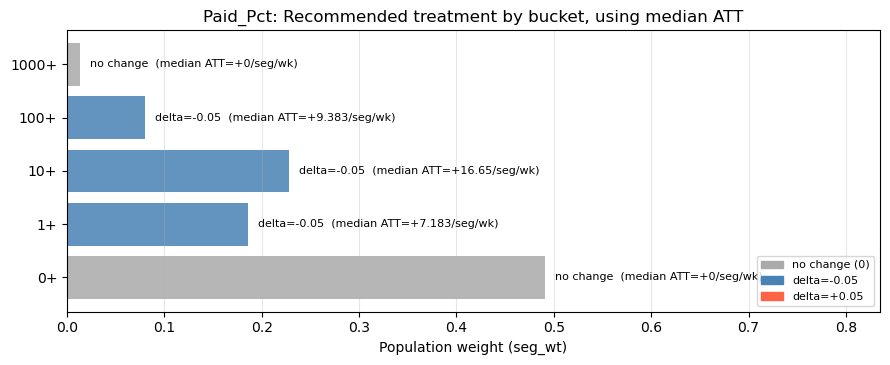

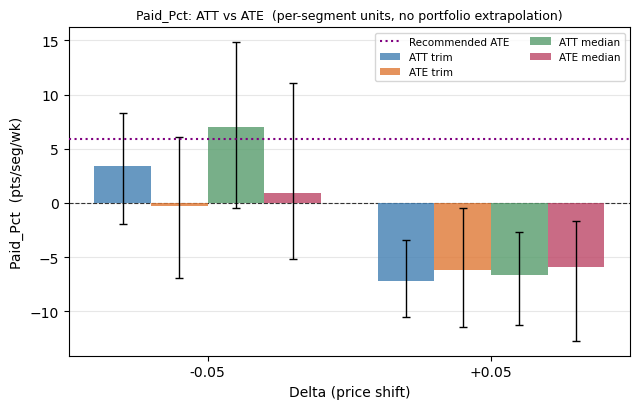


  METRIC: Paid_Pct_Percentile   (quality/rate metric)

ATT by bucket x delta  [Paid_Pct_Percentile / seg / wk]
                delta=-0.05  delta=+0.05
  1000+       (seg_wt=0.0137)
    mean         -2.0333 (n=5)       -2.5200 (n=5)  
    trim10%       -2.0333 (n=5)       -2.5200 (n=5)  
    median       -1.2167 (n=5)       -1.5667 (n=5)  
  100+        (seg_wt=0.0804)
    mean         +2.4763 (n=27)       -2.4435 (n=27)  
    trim10%       +2.4942 (n=27)       -2.5384 (n=27)  
    median       +2.6167 (n=27)       -3.3500 (n=27)  
  10+         (seg_wt=0.2284)
    mean         +1.5244 (n=76)       -1.9267 (n=76)  
    trim10%       +2.1667 (n=76)       -1.6457 (n=76)  
    median       +4.1833 (n=76)       -1.5917 (n=76)  
  1+          (seg_wt=0.1863)
    mean         +0.2840 (n=41)       -0.6794 (n=42)  
    trim10%       +0.6703 (n=41)       -1.7763 (n=42)  
    median       +0.6167 (n=41)       -2.3417 (n=42)  
  0+          (seg_wt=0.4912)
    mean         -1.2449 (n=62)       -

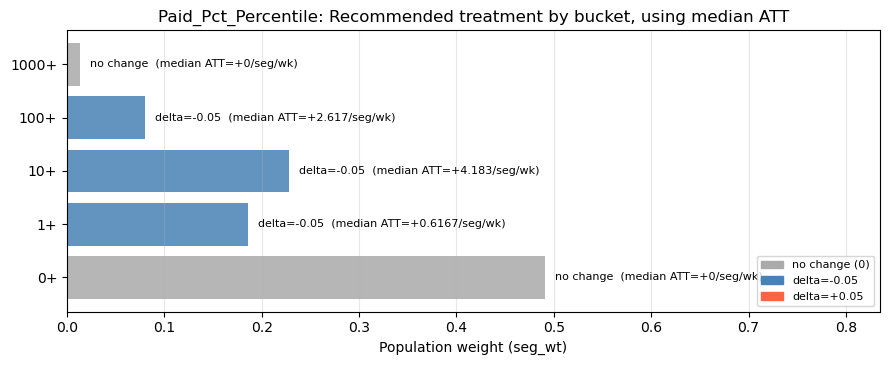

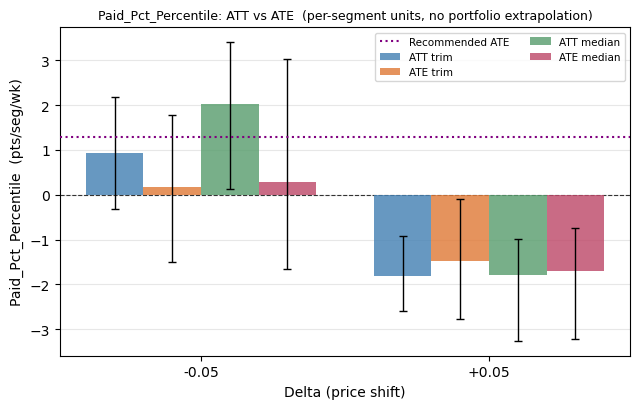

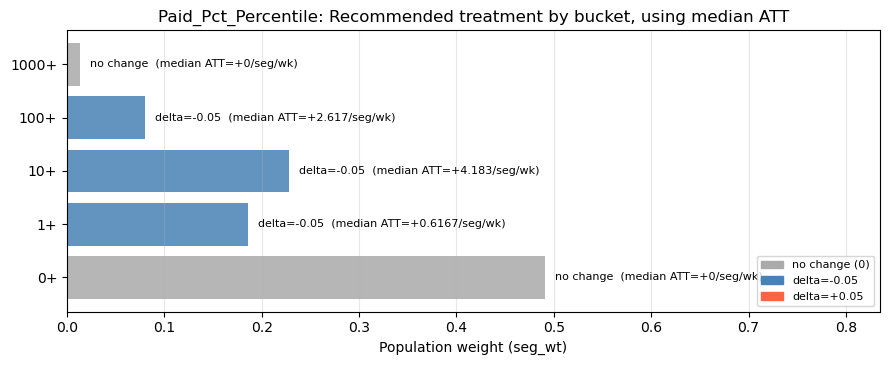

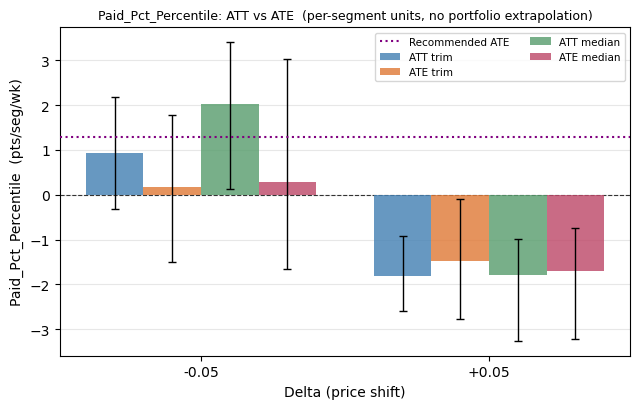

In [40]:
ate_results = {}
for y in Y_VARS:
    ate_results[y] = run_ate_for_metric(y, seg_wt, bkts, n_univ)